In [14]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math


In [15]:
# AMOXICILLIN PK — three-compartment oral model
gamma1 = 1.02   # h^-1  gut → blood absorption
w1     = 0.31   # h^-1  fecal loss (31%)
w2     = 0.68   # h^-1  renal clearance
gamma2 = 0.92   # h^-1  blood → lung ELF
gamma3 = 1.99   # h^-1  lung → blood return

T_AMOX_START = 72.0   # h  treatment begins at day 3

def A_input(t):
    """500 mg oral amoxicillin q8h, starting at T_AMOX_START."""
    if t < T_AMOX_START:
        return 0.0
    if math.floor(t - T_AMOX_START) % 8 == 0:
        return 500.0   # mg
    return 0.0

# AMOXICILLIN PD — Hill killing term (unit-consistent)
# C_tissue [µg/mL] = (a_blood [mg] / V_blood [mL]) × 1000 × f_partition
# f_lung/plasma ≈ 0.4  (amoxicillin lung tissue/plasma ratio, literature)
# f_nasal/plasma ≈ 0.5 (nasal mucosa is well-perfused)
# EC50 = MIC ≈ 0.06 µg/mL (susceptible S. pneumoniae, EUCAST breakpoint)
# k_max = 3 × r_growth ≈ 0.171 h^-1 (bactericidal ceiling for β-lactams)
# n = 1.5 (sigmoidal Hill — steeper threshold than linear)

V_blood    = 5000.0   # mL
f_lp       = 0.40     # lung/plasma partition ratio
f_np       = 0.50     # nasal tissue/plasma partition ratio

k_max_amox = 3 * 0.057   # h^-1
EC50_amox  = 0.06         # µg/mL
n_hill     = 1.5

def amox_kill(a_blood_mg, f_partition):
    """Hill PD killing rate [h^-1] given blood drug mass and tissue partition ratio."""
    C = (a_blood_mg / V_blood) * 1000.0 * f_partition   # µg/mL
    return k_max_amox * C**n_hill / (EC50_amox**n_hill + C**n_hill)


In [16]:

# BIOLOGICAL PARAMETERS

V_lung    = 3000.0   # mL
r_growth  = 0.057    # h^-1  S. pneumoniae growth rate

# Nasal compartment
K_max_nasal  = 1e6     # CFU/mL
B0_nasal     = 1.6e4   # CFU/mL  initial colonisation at symptom onset

# Lung compartment
K_max_lung   = 2.3e8   # CFU/mL  (lower respiratory tract)
B0_lung      = 0.0     # CFU/mL  starts sterile

# Microaspiration: nasal bacteria seed lung
# asp_flux [CFU/mL/h] = microasp_coeff × B_nasal(t)
# This is the key nasal→lung coupling — it's DYNAMIC not constant
microasp_coeff = 0.001   # h^-1  fraction of nasal density aspirated per hour

# Mucociliary clearance
gamma_h = 0.02    # h^-1  healthy
gamma_a = 0.012   # h^-1  asthmatic (~40% lower beat frequency)

# Mucus
sigma_basal  = 0.5    # mL/h
sigma_infect = 2.0    # mL/h
Kmp          = 1e6    # CFU/mL
Mv0_h = sigma_basal / gamma_h   # 25 mL
Mv0_a = sigma_basal / gamma_a   # ~42 mL

# Alveolar macrophages
MA0              = 14e9    # cells
Km               = 5e6     # CFU/mL  phagocytic half-saturation
sigma_ma         = 0.02    # h^-1  recruitment rate
MA_lifespan_h    = 1000.0  # h  (~42 days, alveolar macrophage literature lifespan)
sigma_death_MA_h = MA0 / MA_lifespan_h         # 1.4×10^7 cells/h
sigma_death_MA_a = MA0 / (MA_lifespan_h * 0.85) # slightly shortened in asthma
K_MA_h           = 1.7e-5   # /cell/h  healthy
K_MA_a           = 8.5e-6   # /cell/h  asthmatic (~50% reduced phagocytic capacity)
sigma_usedup_MA  = 0.01

# Neutrophils
N_max          = 8e9
delta_N_h      = 1.0 / 12.0    # h^-1  12 h lifespan (healthy)
delta_N_a      = 1.0 / 48.0    # h^-1  48 h lifespan (asthmatic — prolonged survival)
K_N_h          = 3.6e-4        # /cell/h
K_N_a          = 0.8e-4        # /cell/h  (~78% reduced killing capacity)
sigma_usedup_N = 0.001
r_N_max        = 5e4 * V_lung  # cells/h  max recruitment flux

# Cytokine (quasi-steady-state)
C0_h       = 0.1    # basal (healthy)
C0_a       = 0.3    # elevated basal (chronic asthmatic inflammation)
alpha_cyt  = 2.0
B_half_cyt = 1e4    # CFU/mL  made to match scale of lung B (100-2000 CFU/mL)
C_half     = 1.0

def cytokine(B, C0):
    """Quasi-steady-state cytokine as a function of bacterial load."""
    return C0 + alpha_cyt * B / (B + B_half_cyt)


In [24]:
# COMBINED ODE SYSTEM  (11 state variables)
# y = [a_gut, a_blood, a_lung,
#      BN, MAN, NN, MvN,
#      BL, MAL, NL, MvL]
#
# p = (gamma_N, sigma_dMA_N, K_MA_N, delta_N_N, K_N_N, C0_N,
#      gamma_L, sigma_dMA_L, K_MA_L, delta_N_L, K_N_L, C0_L)

def combined_odes(t, y, p):
    a_gut, a_blood, a_lung, BN, MAN, NN, MvN, BL, MAL, NL, MvL = y
    (gN, sdN, KmaN, dNn, KnN, C0N,
     gL, sdL, KmaL, dNl, KnL, C0L) = p

    # clamp negatives
    a_gut=max(a_gut,0); a_blood=max(a_blood,0); a_lung=max(a_lung,0)
    BN=max(BN,0); MAN=max(MAN,0); NN=max(NN,0); MvN=max(MvN,1e-6)
    BL=max(BL,0); MAL=max(MAL,0); NL=max(NL,0); MvL=max(MvL,1e-6)

    # Amoxicillin PK
    da_gut   = A_input(t) - (gamma1 + w1) * a_gut
    da_blood = 0.85* gamma1 * a_gut - (w2 + gamma2) * a_blood + gamma3 * a_lung
    da_lung  = gamma2 * a_blood - gamma3 * a_lung

    # PD killing rates [h^-1]
    # Both driven by blood level via tissue/plasma partition ratios
    l_lung  = amox_kill(a_blood, f_lp)   # lung tissue
    l_nasal = amox_kill(a_blood, f_np)   # nasal mucosa

    # Nasal → Lung microaspiration [CFU/mL/h]
    asp_flux = microasp_coeff * BN

    # NASAL
    CN      = cytokine(BN, C0N)
    MvNr    = sigma_basal / gN                        # reference (no infection)
    muco_N  = gN * BN * (MvNr / MvN)                  # impaired if Mv > ref
    kma_N   = KmaN * MAN * BN / (Km + BN)
    kn_N    = KnN  * NN  * BN / (Km + BN)

    dBN  = (r_growth * BN * (1 - BN / K_max_nasal)
            - muco_N - kma_N - kn_N - l_nasal * BN)

    dMAN = sigma_ma * (MA0 - MAN) - sdN - sigma_usedup_MA * kma_N

    S_NN = r_N_max * CN/(CN+C_half) * max(0.0, 1.0 - NN/N_max)
    dNN  = S_NN - dNn * NN - sigma_usedup_N * kn_N

    dMvN = sigma_basal + sigma_infect * BN/(Kmp+BN) - gN * MvN

    # LUNG
    CL      = cytokine(BL, C0L)
    MvLr    = sigma_basal / gL
    muco_L  = gL * BL * (MvLr / MvL)
    kma_L   = KmaL * MAL * BL / (Km + BL)
    kn_L    = KnL  * NL  * BL / (Km + BL)

    dBL  = (r_growth * BL * (1 - BL / K_max_lung)
            + asp_flux                               # seeded from nasal
            - muco_L - kma_L - kn_L
            - l_lung * BL)                           # amoxicillin kills

    dMAL = sigma_ma * (MA0 - MAL) - sdL - sigma_usedup_MA * kma_L

    S_NL = r_N_max * CL/(CL+C_half) * max(0.0, 1.0 - NL/N_max)
    dNL  = S_NL - dNl * NL - sigma_usedup_N * kn_L

    dMvL = sigma_basal + sigma_infect * BL/(Kmp+BL) - gL * MvL

    return [da_gut, da_blood, da_lung,
            dBN, dMAN, dNN, dMvN,
            dBL, dMAL, dNL, dMvL]


In [25]:

# INITIAL CONDITIONS & SOLVE  (14-day simulation)

N0_init = 0.05 * N_max   # 5% of max neutrophils at t=0

p_h = (gamma_h, sigma_death_MA_h, K_MA_h, delta_N_h, K_N_h, C0_h,
       gamma_h, sigma_death_MA_h, K_MA_h, delta_N_h, K_N_h, C0_h)
p_a = (gamma_a, sigma_death_MA_a, K_MA_a, delta_N_a, K_N_a, C0_a,
       gamma_a, sigma_death_MA_a, K_MA_a, delta_N_a, K_N_a, C0_a)

y0_h = [0, 0, 0, B0_nasal, MA0, N0_init, Mv0_h,
        B0_lung, MA0, N0_init, Mv0_h]
y0_a = [0, 0, 0, B0_nasal, MA0, N0_init, Mv0_a,
        B0_lung, MA0, N0_init, Mv0_a]

tspan = np.linspace(0, 336, 10000)   # 14 days

sol_h = solve_ivp(lambda t, y: combined_odes(t, y, p_h),
                  [0, 336], y0_h, t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)
sol_a = solve_ivp(lambda t, y: combined_odes(t, y, p_a),
                  [0, 336], y0_a, t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)

print(f"Healthy solver:   {'SUCCESS' if sol_h.success else 'FAILED'}")
print(f"Asthmatic solver: {'SUCCESS' if sol_a.success else 'FAILED'}")
print()

# Print key clinical summary
tpts = {t: np.argmin(abs(tspan - t)) for t in [24, 48, 72, 96, 120, 168, 240, 336]}
print("Lung B_L (CFU/mL):")
print(f"  Healthy:   ", {f't={t}h': f'{sol_h.y[7][i]:.1e}' for t, i in tpts.items()})
print(f"  Asthmatic: ", {f't={t}h': f'{sol_a.y[7][i]:.1e}' for t, i in tpts.items()})
print()
print(f"Peak lung load — healthy: {sol_h.y[7].max():.1e} CFU/mL  |  "
      f"asthmatic: {sol_a.y[7].max():.1e} CFU/mL  ({sol_a.y[7].max()/sol_h.y[7].max():.1f}× higher)")
print()
C_peak_h = (sol_h.y[1].max() / V_blood) * 1000 * f_lp
print(f"Peak lung tissue amoxicillin: {C_peak_h:.1f} µg/mL  (MIC = {EC50_amox} µg/mL  →  {C_peak_h/EC50_amox:.0f}× MIC)")

Healthy solver:   SUCCESS
Asthmatic solver: SUCCESS

Lung B_L (CFU/mL):
  Healthy:    {'t=24h': '1.5e+02', 't=48h': '1.2e+02', 't=72h': '8.1e+01', 't=96h': '1.4e+01', 't=120h': '1.6e-01', 't=168h': '2.0e-05', 't=240h': '2.7e-11', 't=336h': '4.0e-19'}
  Asthmatic:  {'t=24h': '4.6e+02', 't=48h': '8.9e+02', 't=72h': '1.1e+03', 't=96h': '1.2e+03', 't=120h': '1.2e+03', 't=168h': '1.2e+00', 't=240h': '5.8e-06', 't=336h': '5.4e-13'}

Peak lung load — healthy: 1.5e+02 CFU/mL  |  asthmatic: 1.2e+03 CFU/mL  (8.2× higher)

Peak lung tissue amoxicillin: 10.5 µg/mL  (MIC = 0.06 µg/mL  →  175× MIC)


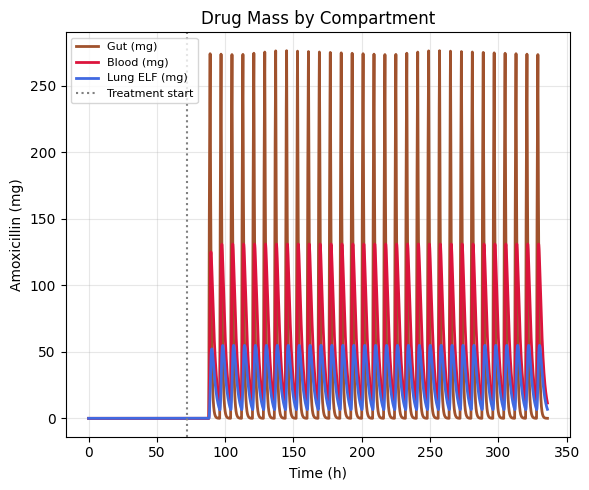

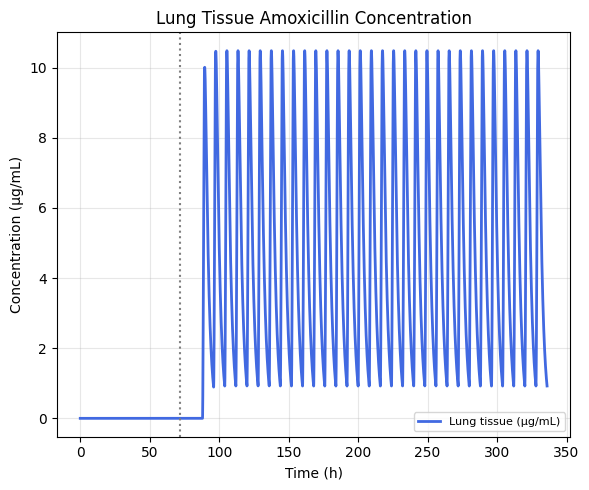

In [34]:

# Mass in each compartment
fig1, ax1 = plt.subplots(figsize=(6,5))

ax1.plot(sol_h.t, sol_h.y[0], color='sienna', lw=2, label='Gut (mg)')
ax1.plot(sol_h.t, sol_h.y[1], color='crimson', lw=2, label='Blood (mg)')
ax1.plot(sol_h.t, sol_h.y[2], color='royalblue', lw=2, label='Lung ELF (mg)')
ax1.axvline(T_AMOX_START, color='grey', ls=':', lw=1.5, label='Treatment start')

ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Amoxicillin (mg)')
ax1.set_title('Drug Mass by Compartment')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig("drug_mass_compartments.jpg", dpi=300, bbox_inches="tight")


# Tissue concentration
fig2, ax2 = plt.subplots(figsize=(6,5))

C_lung_h = sol_h.y[1] * 1000 / V_blood * f_lp

ax2.plot(sol_h.t, C_lung_h, color='royalblue', lw=2, label='Lung tissue (µg/mL)')
ax2.axvline(T_AMOX_START, color='grey', ls=':', lw=1.5)

ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Concentration (µg/mL)')
ax2.set_title('Lung Tissue Amoxicillin Concentration')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig("lung_concentration.jpg", dpi=300, bbox_inches="tight")

plt.show()

plt.close(fig1)
plt.close(fig2)



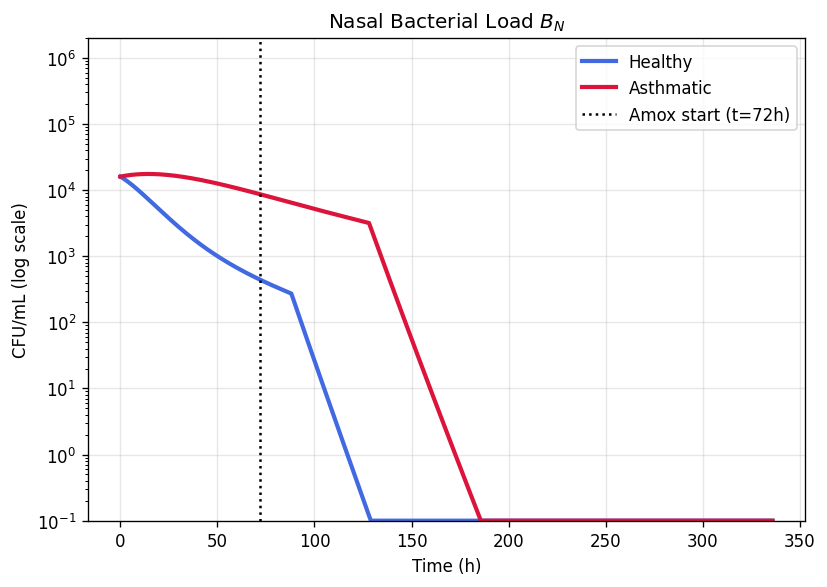

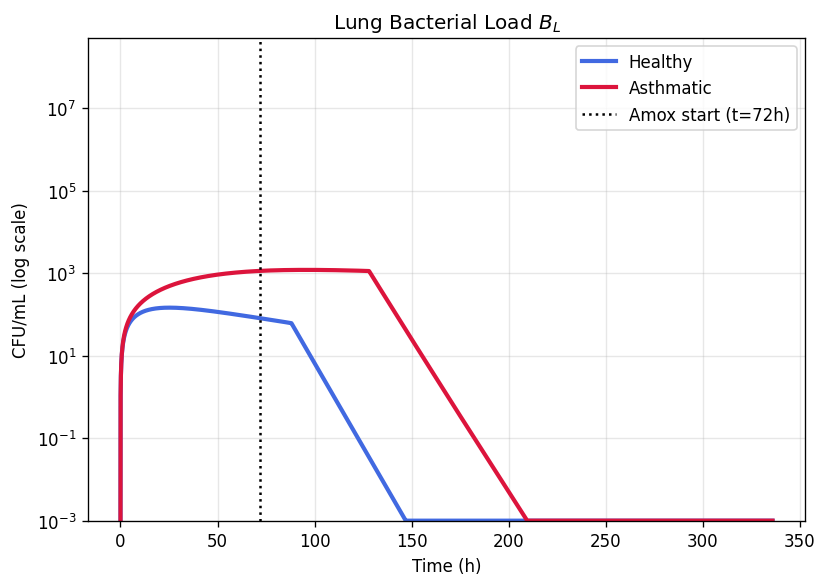

KEY RESULTS:
  Healthy peak lung B:   146 CFU/mL (t=25h)
  Asthmatic peak lung B: 1198 CFU/mL (t=96h)
  Healthy cleared to <0.01 CFU/mL at t~0h
  Asthmatic cleared to <0.01 CFU/mL at t~0h


In [45]:

kw_h = dict(color='royalblue', lw=2.5, label='Healthy')
kw_a = dict(color='crimson',   lw=2.5, label='Asthmatic')

# ----------------------------
# FIGURE A — Nasal clearance
# ----------------------------
figN, axN = plt.subplots(figsize=(7, 5), dpi=120)

axN.plot(sol_h.t, np.maximum(sol_h.y[3], 1e-1), **kw_h)
axN.plot(sol_a.t, np.maximum(sol_a.y[3], 1e-1), **kw_a)
axN.axvline(T_AMOX_START, color='black', ls=':', lw=1.5,
            label='Amox start (t=72h)')

axN.set_yscale('log')
axN.set_ylim(1e-1, 2e6)
axN.set_title('Nasal Bacterial Load $B_N$')
axN.set_ylabel('CFU/mL (log scale)')
axN.set_xlabel('Time (h)')
axN.legend()
axN.grid(True, alpha=0.3)

figN.tight_layout()
figN.savefig("nasal_bacterial_load.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figN)

# FIGURE B — Lung clearance
# ----------------------------
figL, axL = plt.subplots(figsize=(7, 5), dpi=120)

axL.plot(sol_h.t, np.maximum(sol_h.y[7], 1e-3), **kw_h)
axL.plot(sol_a.t, np.maximum(sol_a.y[7], 1e-3), **kw_a)
axL.axvline(T_AMOX_START, color='black', ls=':', lw=1.5,
            label='Amox start (t=72h)')

axL.set_yscale('log')
axL.set_ylim(1e-3, 5e8)
axL.set_title('Lung Bacterial Load $B_L$')
axL.set_ylabel('CFU/mL (log scale)')
axL.set_xlabel('Time (h)')
axL.legend()
axL.grid(True, alpha=0.3)

figL.tight_layout()
figL.savefig("lung_bacterial_load.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figL)

print("KEY RESULTS:")
print(f"  Healthy peak lung B:   {sol_h.y[7].max():.0f} CFU/mL (t={tspan[sol_h.y[7].argmax()]:.0f}h)")
print(f"  Asthmatic peak lung B: {sol_a.y[7].max():.0f} CFU/mL (t={tspan[sol_a.y[7].argmax()]:.0f}h)")

i_clear_h = np.where(sol_h.y[7] < 0.01)[0]
i_clear_a = np.where(sol_a.y[7] < 0.01)[0]
if len(i_clear_h): print(f"  Healthy cleared to <0.01 CFU/mL at t~{tspan[i_clear_h[0]]:.0f}h")
if len(i_clear_a): print(f"  Asthmatic cleared to <0.01 CFU/mL at t~{tspan[i_clear_a[0]]:.0f}h")

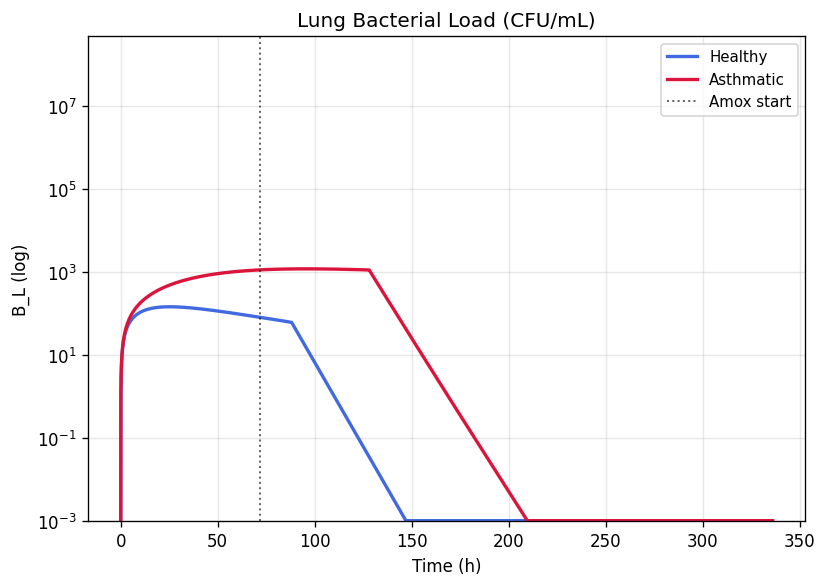

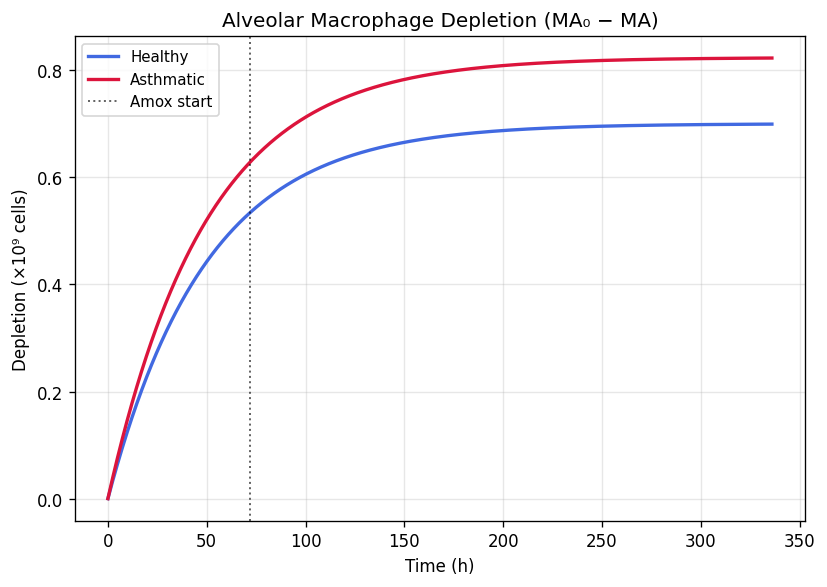

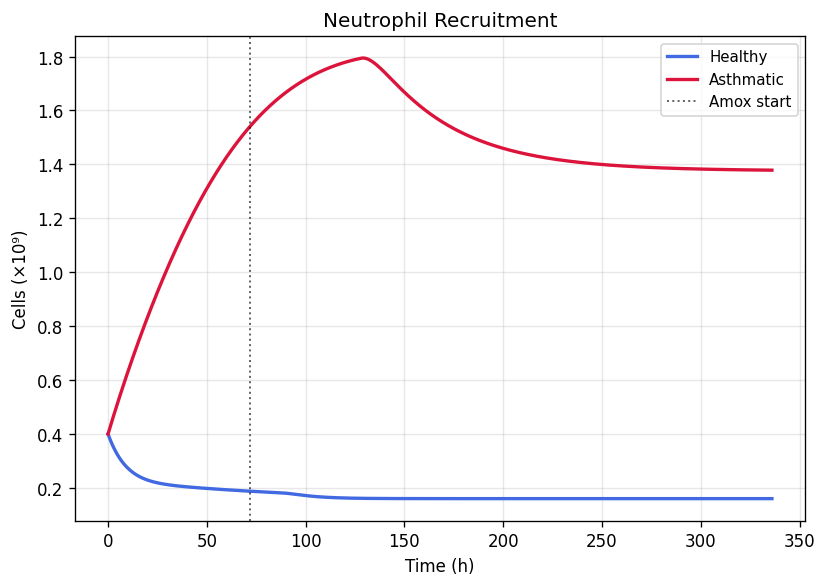

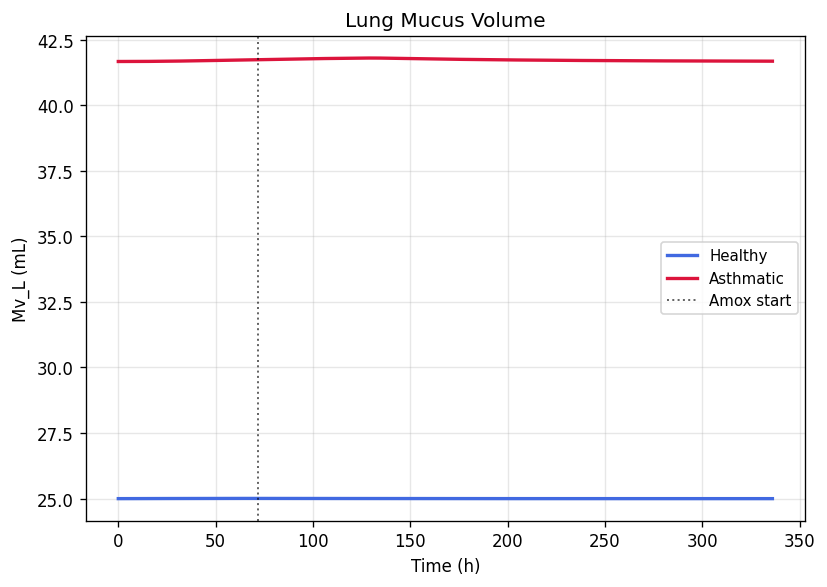

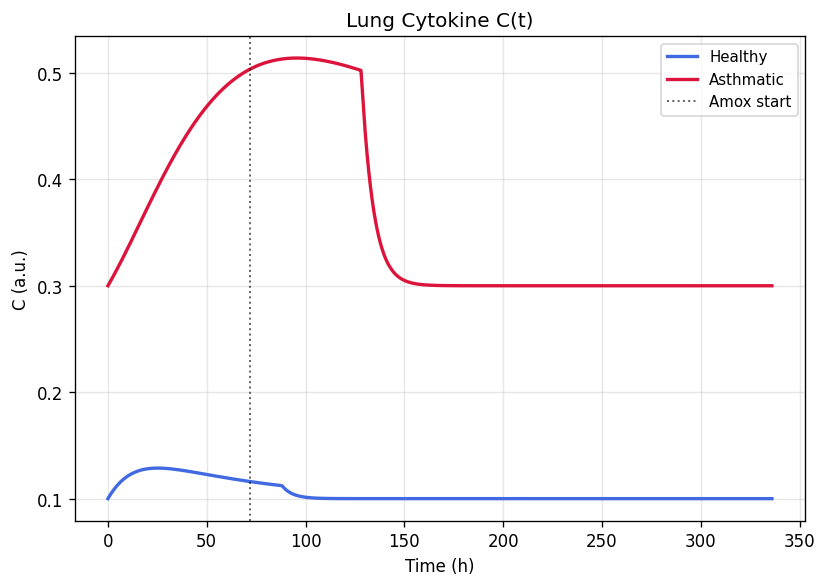

In [44]:

# PLOT 3 — Full immune response (6-panel)

def add_amox_line(ax):
    ax.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6)

# Bacteria
fig1, ax1 = plt.subplots(figsize=(7,5), dpi=120)

ax1.plot(sol_h.t, np.maximum(sol_h.y[7], 1e-3), **kw_h)
ax1.plot(sol_a.t, np.maximum(sol_a.y[7], 1e-3), **kw_a)
ax1.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6,label='Amox start')

ax1.set_yscale('log')
ax1.set_ylim(1e-3, 5e8)
ax1.set_title('Lung Bacterial Load (CFU/mL)')
ax1.set_ylabel('B_L (log)')
ax1.set_xlabel('Time (h)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig("immune_lung_bacteria.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig1)

# Macrophages
fig2, ax2 = plt.subplots(figsize=(7,5), dpi=120)

MA_dev_h = (MA0 - sol_h.y[8]) / 1e9
MA_dev_a = (MA0 - sol_a.y[8]) / 1e9

ax2.plot(sol_h.t, MA_dev_h, **kw_h)
ax2.plot(sol_a.t, MA_dev_a, **kw_a)
ax2.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax2.set_title('Alveolar Macrophage Depletion (MA₀ − MA)')
ax2.set_ylabel('Depletion (×10⁹ cells)')
ax2.set_xlabel('Time (h)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig("immune_macrophage_depletion.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig2)

# Neutrophils
fig3, ax3 = plt.subplots(figsize=(7,5), dpi=120)

ax3.plot(sol_h.t, sol_h.y[9] / 1e9, **kw_h)
ax3.plot(sol_a.t, sol_a.y[9] / 1e9, **kw_a)
ax3.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax3.set_title('Neutrophil Recruitment')
ax3.set_ylabel('Cells (×10⁹)')
ax3.set_xlabel('Time (h)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig3.tight_layout()
fig3.savefig("immune_neutrophils.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig3)

# Mucus
fig4, ax4 = plt.subplots(figsize=(7,5), dpi=120)

ax4.plot(sol_h.t, sol_h.y[10], **kw_h)
ax4.plot(sol_a.t, sol_a.y[10], **kw_a)
ax4.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax4.set_title('Lung Mucus Volume')
ax4.set_ylabel('Mv_L (mL)')
ax4.set_xlabel('Time (h)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

fig4.tight_layout()
fig4.savefig("immune_mucus_volume.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig4)

# Cytokine
fig5, ax5 = plt.subplots(figsize=(7,5), dpi=120)

ax5.plot(sol_h.t, C_h_L, **kw_h)
ax5.plot(sol_a.t, C_a_L, **kw_a)
ax5.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax5.set_title('Lung Cytokine C(t)')
ax5.set_ylabel('C (a.u.)')
ax5.set_xlabel('Time (h)')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

fig5.tight_layout()
fig5.savefig("immune_cytokine.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig5)



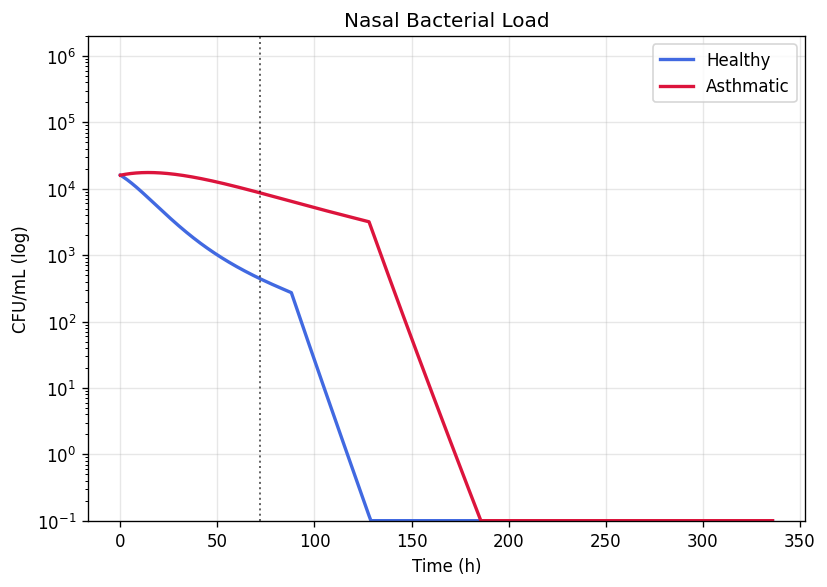

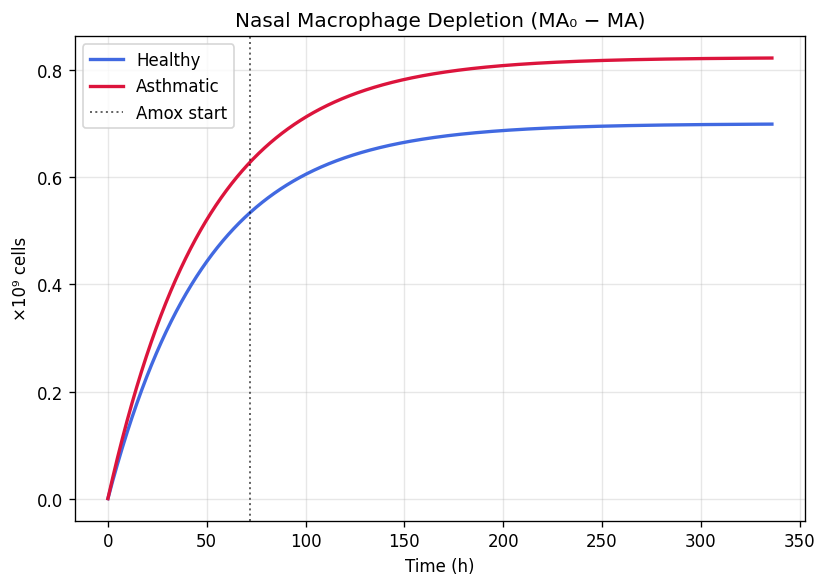

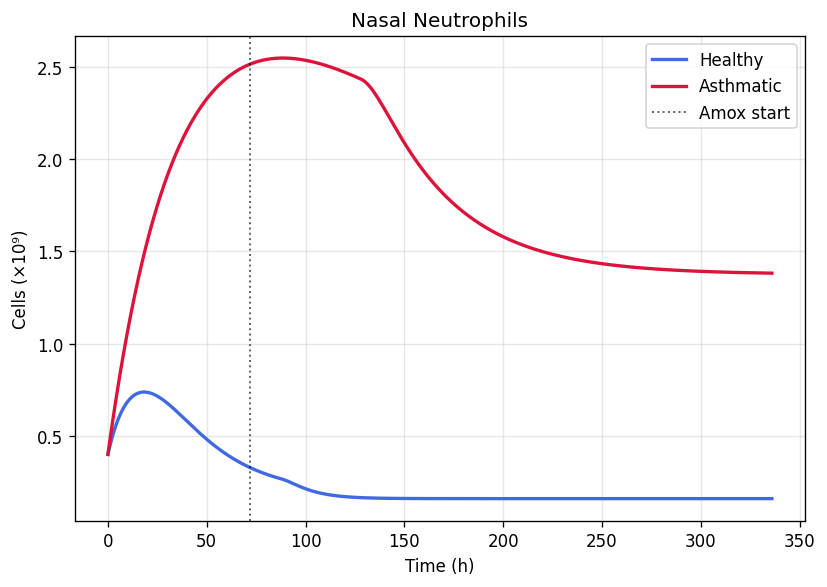

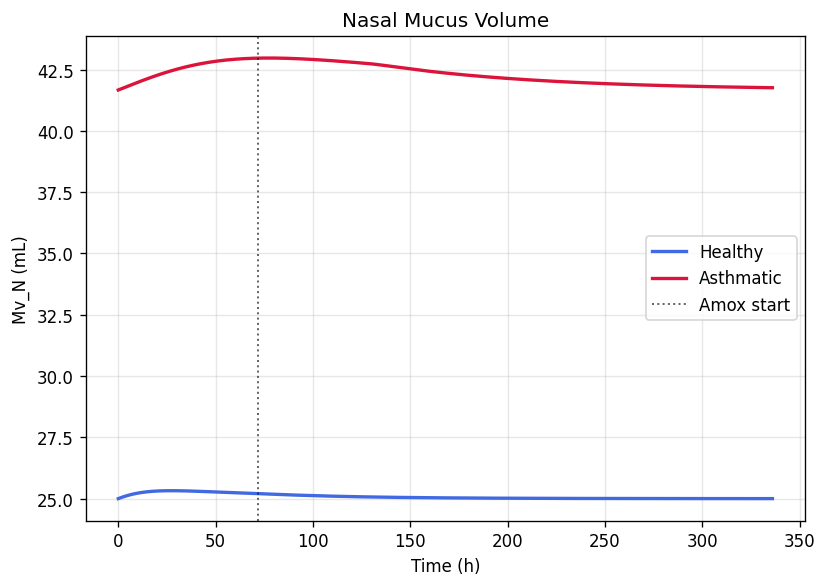

In [43]:

# PLOT 4 — Nasal immune response (mirrors lung plots)

kw_h = dict(color='royalblue', lw=2, label='Healthy')
kw_a = dict(color='crimson',   lw=2, label='Asthmatic')

fig1, ax1 = plt.subplots(figsize=(7,5), dpi=120)

ax1.plot(sol_h.t, np.maximum(sol_h.y[3], 1e-1), **kw_h)
ax1.plot(sol_a.t, np.maximum(sol_a.y[3], 1e-1), **kw_a)
ax1.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax1.set_yscale('log')
ax1.set_ylim(1e-1, 2e6)
ax1.set_title('Nasal Bacterial Load')
ax1.set_ylabel('CFU/mL (log)')
ax1.set_xlabel('Time (h)')
ax1.legend()
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig("nasal_bacterial_load_full.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(7,5), dpi=120)

MA_dev_h_N = (MA0 - sol_h.y[4]) / 1e9
MA_dev_a_N = (MA0 - sol_a.y[4]) / 1e9

ax2.plot(sol_h.t, MA_dev_h_N, **kw_h)
ax2.plot(sol_a.t, MA_dev_a_N, **kw_a)
ax2.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax2.set_title('Nasal Macrophage Depletion (MA₀ − MA)')
ax2.set_ylabel('×10⁹ cells')
ax2.set_xlabel('Time (h)')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig("nasal_macrophage_depletion.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig2)

fig3, ax3 = plt.subplots(figsize=(7,5), dpi=120)

ax3.plot(sol_h.t, sol_h.y[5] / 1e9, **kw_h)
ax3.plot(sol_a.t, sol_a.y[5] / 1e9, **kw_a)
ax3.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax3.set_title('Nasal Neutrophils')
ax3.set_ylabel('Cells (×10⁹)')
ax3.set_xlabel('Time (h)')
ax3.legend()
ax3.grid(True, alpha=0.3)

fig3.tight_layout()
fig3.savefig("nasal_neutrophils.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig3)

fig4, ax4 = plt.subplots(figsize=(7,5), dpi=120)

ax4.plot(sol_h.t, sol_h.y[6], **kw_h)
ax4.plot(sol_a.t, sol_a.y[6], **kw_a)
ax4.axvline(T_AMOX_START, color='black', ls=':', lw=1.2, alpha=0.6, label='Amox start')

ax4.set_title('Nasal Mucus Volume')
ax4.set_ylabel('Mv_N (mL)')
ax4.set_xlabel('Time (h)')
ax4.legend()
ax4.grid(True, alpha=0.3)

fig4.tight_layout()
fig4.savefig("nasal_mucus_volume.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig4)



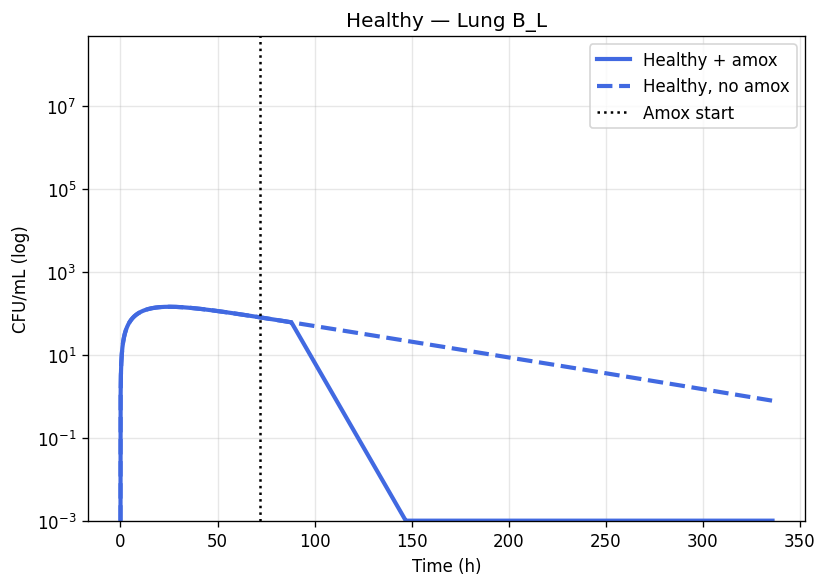

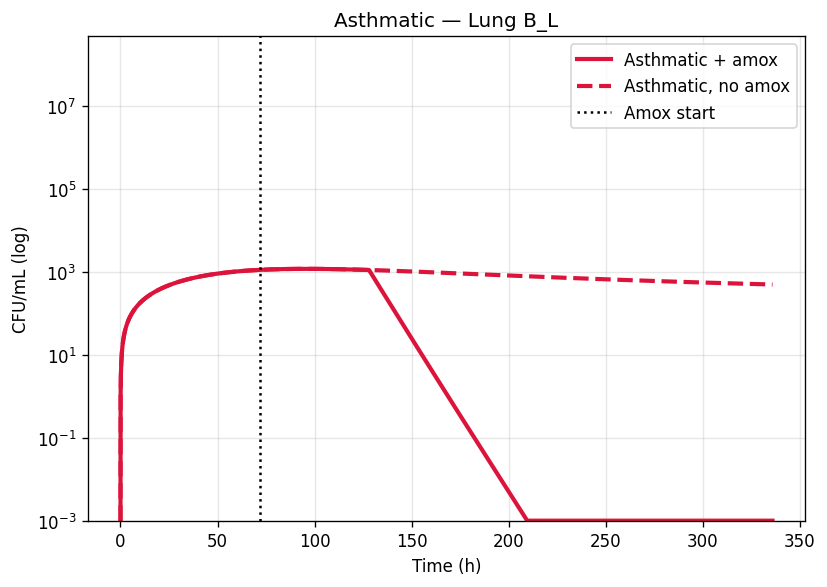

No-treatment peak lung B:  healthy = 1.46e+02  asthmatic = 1.20e+03


In [42]:

# PLOT 5 — Treatment comparison: with vs without amoxicillin

# no treatment
sol_h_no = solve_ivp(lambda t, y: combined_odes(t, y, p_h),
                     [0, 336],
                     [0,0,0, B0_nasal, MA0, N0_init, Mv0_h,
                      B0_lung, MA0, N0_init, Mv0_h],
                     t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10,
                     args=())

# A_input to return 0 always for no-treatment run
import types
_orig_A_input = A_input

def A_input_off(t):
    return 0.0

import builtins
# local solve
import __main__; __main__.A_input = A_input_off
A_input = A_input_off

sol_h_no  = solve_ivp(lambda t,y: combined_odes(t,y,p_h), [0,336],
                      [0,0,0,B0_nasal,MA0,N0_init,Mv0_h,B0_lung,MA0,N0_init,Mv0_h],
                      t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)
sol_a_no  = solve_ivp(lambda t,y: combined_odes(t,y,p_a), [0,336],
                      [0,0,0,B0_nasal,MA0,N0_init,Mv0_a,B0_lung,MA0,N0_init,Mv0_a],
                      t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)

A_input = _orig_A_input   # restore

fig1, ax1 = plt.subplots(figsize=(7,5), dpi=120)

ax1.set_title('Healthy — Lung B_L')

ax1.plot(tspan, np.maximum(sol_h.y[7], 1e-3),
         color='royalblue', lw=2.5, label='Healthy + amox')

ax1.plot(tspan, np.maximum(sol_h_no.y[7], 1e-3),
         color='royalblue', lw=2.5, ls='--',
         label='Healthy, no amox')

ax1.axvline(T_AMOX_START, color='black', ls=':', lw=1.5,
            label='Amox start')

ax1.set_yscale('log')
ax1.set_ylim(1e-3, 5e8)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('CFU/mL (log)')
ax1.legend()
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig("treatment_effect_healthy.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(7,5), dpi=120)

ax2.set_title('Asthmatic — Lung B_L')

ax2.plot(tspan, np.maximum(sol_a.y[7], 1e-3),
         color='crimson', lw=2.5, label='Asthmatic + amox')

ax2.plot(tspan, np.maximum(sol_a_no.y[7], 1e-3),
         color='crimson', lw=2.5, ls='--',
         label='Asthmatic, no amox')

ax2.axvline(T_AMOX_START, color='black', ls=':', lw=1.5,
            label='Amox start')

ax2.set_yscale('log')
ax2.set_ylim(1e-3, 5e8)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('CFU/mL (log)')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig("treatment_effect_asthmatic.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig2)

print("No-treatment peak lung B:  healthy =", f"{sol_h_no.y[7].max():.2e}",
      " asthmatic =", f"{sol_a_no.y[7].max():.2e}")
